<a href="https://colab.research.google.com/github/JustJess21/JesseE/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

k =  1, Mean accuracy = 0.9600
k =  2, Mean accuracy = 0.9533
k =  3, Mean accuracy = 0.9667
k =  4, Mean accuracy = 0.9667
k =  5, Mean accuracy = 0.9667
k =  6, Mean accuracy = 0.9667
k =  7, Mean accuracy = 0.9667
k =  8, Mean accuracy = 0.9667
k =  9, Mean accuracy = 0.9733
k = 10, Mean accuracy = 0.9667
k = 11, Mean accuracy = 0.9667
k = 12, Mean accuracy = 0.9733
k = 13, Mean accuracy = 0.9800
k = 14, Mean accuracy = 0.9733
k = 15, Mean accuracy = 0.9733
k = 16, Mean accuracy = 0.9733
k = 17, Mean accuracy = 0.9733
k = 18, Mean accuracy = 0.9800
k = 19, Mean accuracy = 0.9733
k = 20, Mean accuracy = 0.9800
k = 21, Mean accuracy = 0.9667
k = 22, Mean accuracy = 0.9667
k = 23, Mean accuracy = 0.9733
k = 24, Mean accuracy = 0.9600
k = 25, Mean accuracy = 0.9667
k = 26, Mean accuracy = 0.9600
k = 27, Mean accuracy = 0.9667
k = 28, Mean accuracy = 0.9533
k = 29, Mean accuracy = 0.9533
k = 30, Mean accuracy = 0.9533

Optimal k: 13

Best Cross-Validation Accuracy: 0.9800000000000001


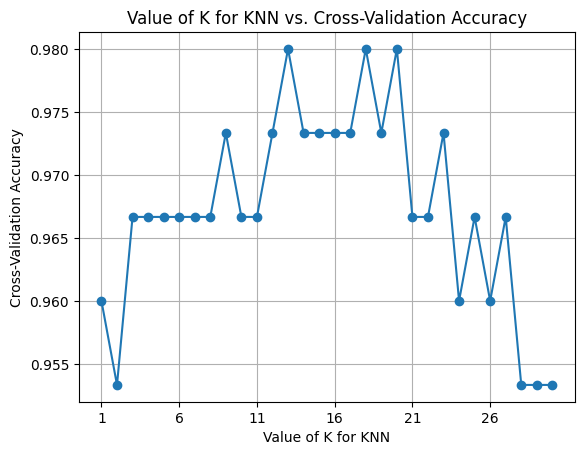

Fitting 10 folds for each of 30 candidates, totalling 300 fits

Best parameters from GridSearchCV: {'n_neighbors': 11}
Best cross-validation accuracy from GridSearchCV: 0.9733333333333334


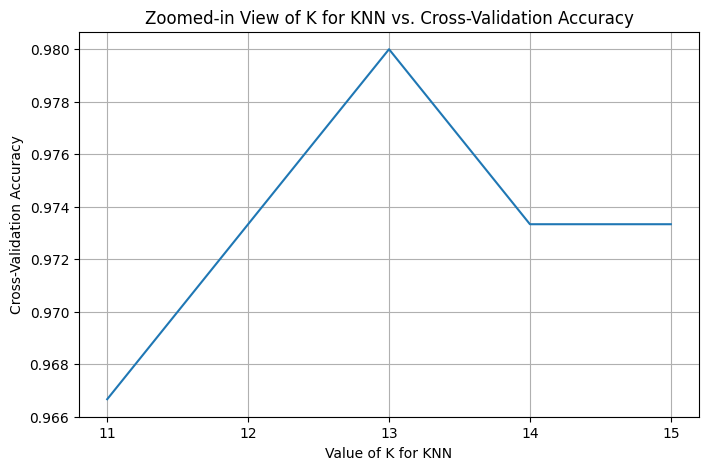

In [21]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score

iris = load_iris()
X = iris.data
y = iris.target

kf = KFold(n_splits=10, random_state=11, shuffle=True)

cv_mean_scores = [] # List to store mean accuracy for each k

k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)

    cv_mean_scores.append(scores.mean()) # Append the mean of the cross-validation scores

    print(f"k = {k:2d}, Mean accuracy = {scores.mean():.4f}") # Print the current k and its mean accuracy

# Find the optimal k and its corresponding best score
best_k_index = cv_mean_scores.index(max(cv_mean_scores))
best_k = k_range[best_k_index]
best_score = max(cv_mean_scores)

print("\nOptimal k:", best_k)
print("\nBest Cross-Validation Accuracy:", best_score)

import matplotlib.pyplot as plt

plt.plot(k_range, cv_mean_scores, marker='o') # Use k_range for x-axis and cv_mean_scores for y-axis
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Value of K for KNN vs. Cross-Validation Accuracy')
plt.xticks(list(k_range)[::5]) # Use k_range for ticks, showing every 5th value for clarity
plt.grid(True)
plt.show()

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {'n_neighbors': k_range} # k_range is already defined as range(1, 31)

# Create a KNN classifier instance
knn = KNeighborsClassifier()

# Create a GridSearchCV object
grid_search = GridSearchCV(knn, param_grid, cv=kf, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the data
grid_search.fit(X, y)

# Print the best parameters and best score
print("\nBest parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation accuracy from GridSearchCV:", grid_search.best_score_)

zoomed_k = [k for k in k_range if 11 <= k <=15]
zoomed_scores = [score for k, score in zip(k_range, cv_mean_scores) if 11 <= k <= 15] # Corrected to use k_range and cv_mean_scores

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(zoomed_k, zoomed_scores) # Use zoomed_k for x-axis and zoomed_scores for y-axis
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Zoomed-in View of K for KNN vs. Cross-Validation Accuracy') # Added a more specific title
plt.xticks(zoomed_k) # Use zoomed_k for integer ticks
plt.grid(True) # Changed to True for better readability in zoomed view
plt.show()